<a href="https://colab.research.google.com/github/hamptb/MANE-4961/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For K = 2, Silhouette Score = 0.6404
For K = 3, Silhouette Score = 0.6898
For K = 4, Silhouette Score = 0.7945
For K = 5, Silhouette Score = 0.7291
For K = 6, Silhouette Score = 0.7440


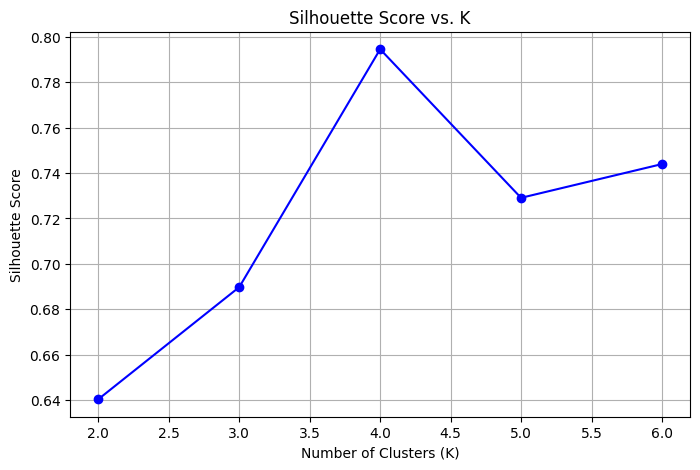

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
df = pd.read_csv('/content/aircraft_performance.csv')

# Select the second and third columns (0-indexed 1 and 2)
X = df.iloc[:, [1, 2]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute silhouette scores for K in 2 to 6
k_values = list(range(2, 7))
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, Silhouette Score = {score:.4f}")

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. K')
plt.grid(True)
plt.show()

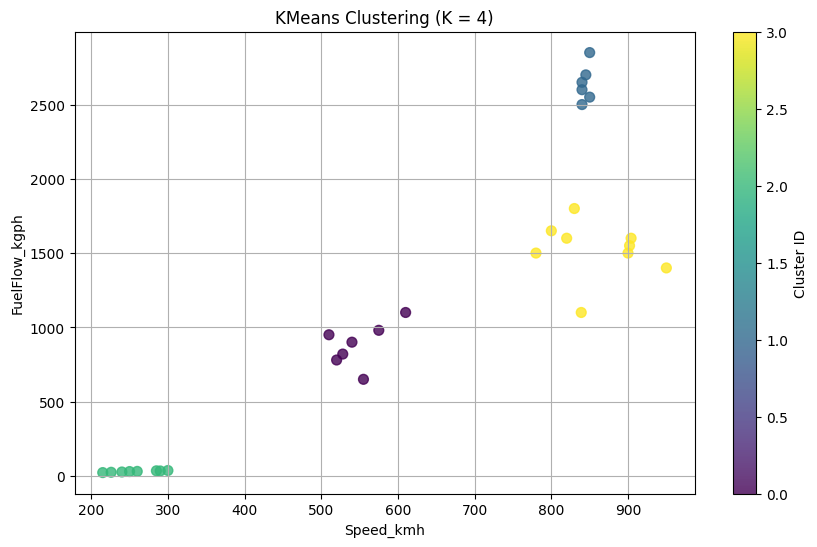

In [ ]:
# Fit KMeans with the selected optimal K = 4
k_optimal = 4
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_optimal.fit_predict(X_scaled)

# Add cluster labels to the original DataFrame for plotting
df['Cluster'] = clusters

# Create a scatter plot using the original scales for better readability
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df.iloc[:, 1], df.iloc[:, 2], c=df['Cluster'], cmap='viridis', s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[2])
plt.title(f'KMeans Clustering (K = {k_optimal})')
plt.grid(True)
plt.show()

The blue cluster in the top right is likely jets, consuming a high amount of fuel and going the fastest. The green cluster in the bottom left is likely personal aircraft, goig slow and not using a lot of fuel. The purple and yellow are somewhere inbetween, maybe different types of passenger planes

2 (40 pts.) Implement your own linear machine learning model optimized with mini-batch
gradient descent method to predict the price of a house in a city with population of 160,
000. Train the model to fit the housing prices dataset found on LMS. Vary the batch size
from 1,5,10, and 20. Plot the objective function, J for each batch size. You do not need to
split the data into train and test set for this problem. What happens when you use batch
size equal to one?

In [ ]:
df = pd.read_csv('housing_prices.txt')
df.columns = ['population','price']
df.head()

,population,price
0,5.5277,9.1302
1,8.5186,13.6620
2,7.0032,11.8540
3,5.8598,6.8233
4,8.3829,11.8860


In [ ]:
x = df['population'].to_numpy()
y = df['price'].to_numpy()

In [ ]:
#defining linear model
w = 0
b = 0
y_hat = w*x + b

In [ ]:
#gradient descent
import numpy as np
m = len(y)
J = 1/(2*m)*(np.sum(y_hat - y)**2)
print(J)

1568.676771754219


In [ ]:
dw = (1/m)*np.sum((y_hat - y)*x)
db = (1/m)*np.sum(y_hat - y)
print(dw)
print(db)

-64.88968277207292
-5.716709375000001


In [ ]:
alpha = 0.01
w = w - alpha*dw
b = b - alpha*db

print(w)
print(b)

0.6488968277207292
0.05716709375000001


In [ ]:
y_hat = w*x + b
J = (1/(2*m)) * np.sum((y_hat - y)**2)

print(J)

5.901469393444238


In [ ]:
#m = 1
w = 0
b = 0
alpha = 0.01
epochs = 100
J_history = []

for epoch in range(epochs):
  y_hat = w*x + b
  J = (1/(2*m)) * np.sum((y_hat - y)**2)
  dw = (1/m)*np.sum((y_hat - y)*x)
  db = (1/m)*np.sum(y_hat - y)
  w = w - alpha*dw
  b = b - alpha*db
  J_history.append(J)

print(w)
print(b)
print(J)


0.8549197441190249
-0.6308876995749794
4.633097746092306


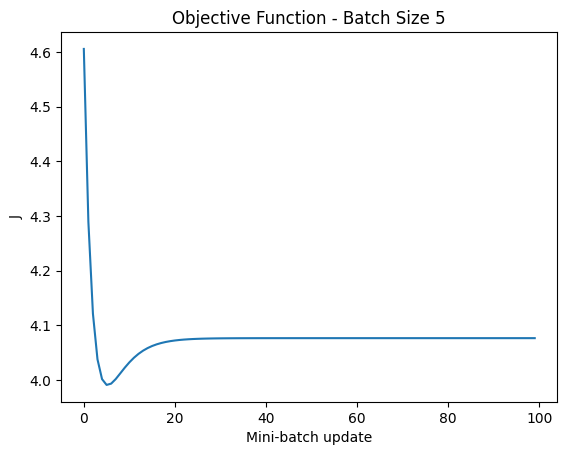

In [ ]:
#m = 1
w = 0
b = 0
alpha = 0.01
epochs = 100
batch_size = 1

J_history_1 = []

m = len(y)

for epoch in range(epochs):
  for start in range(0, m, batch_size):
    end = start + batch_size
    x_batch = x[start:end]
    y_batch = y[start:end]

    m_batch = len(y_batch)

    y_hat = w*x_batch + b
    J = (1/(2*m_batch)) * np.sum((y_hat - y_batch)**2)
    dw = (1/m_batch)*np.sum((y_hat - y_batch)*x_batch)
    db = (1/m_batch)*np.sum(y_hat - y_batch)
    w = w - alpha*dw
    b = b - alpha*db

  # Calculate J using ALL data after the epoch
  y_hat_all = w*x + b
  J = (1/(2*m))*np.sum((y_hat_all - y)**2)

  J_history_1.append(J)


plt.plot(J_history_1)

plt.xlabel("Mini-batch update")
plt.ylabel("J")
plt.title("Objective Function - Batch Size 5")

plt.show()

In [ ]:
#m = 5
w = 0
b = 0
alpha = 0.01
epochs = 100
batch_size = 5

J_history_5 = []

m = len(y)

for epoch in range(epochs):
  for start in range(0, m, batch_size):
    end = start + batch_size
    x_batch = x[start:end]
    y_batch = y[start:end]

    m_batch = len(y_batch)

    y_hat = w*x_batch + b
    J = (1/(2*m_batch)) * np.sum((y_hat - y_batch)**2)
    dw = (1/m_batch)*np.sum((y_hat - y_batch)*x_batch)
    db = (1/m_batch)*np.sum(y_hat - y_batch)
    w = w - alpha*dw
    b = b - alpha*db

  # Calculate J using ALL data after the epoch
  y_hat_all = w*x + b
  J = (1/(2*m))*np.sum((y_hat_all - y)**2)

  J_history_5.append(J)

print(w)
print(b)
print(J)

0.936303798731952
-3.7763154854411507
5.713351173015004


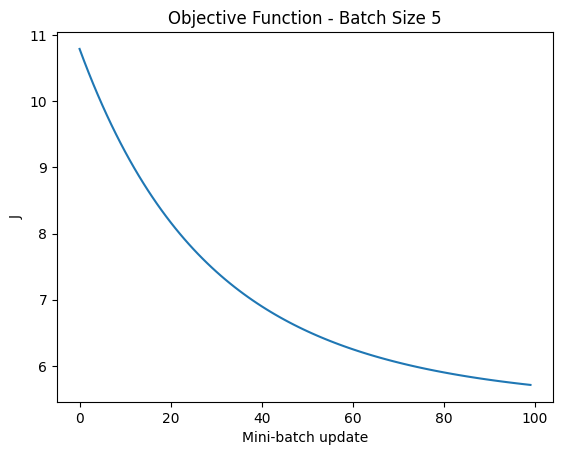

In [ ]:
plt.plot(J_history_5)

plt.xlabel("Mini-batch update")
plt.ylabel("J")
plt.title("Objective Function - Batch Size 5")

plt.show()

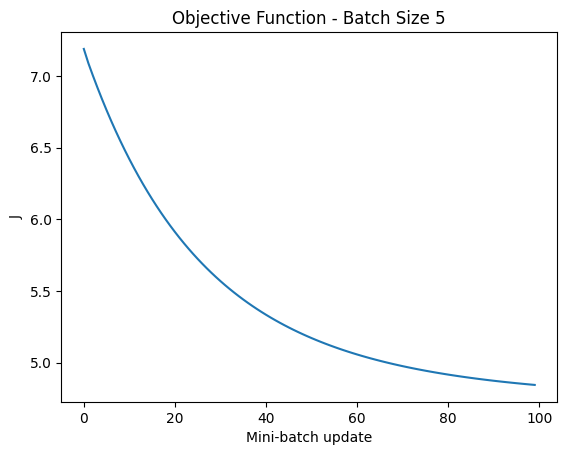

In [ ]:
#m = 10
w = 0
b = 0
alpha = 0.01
epochs = 100
batch_size = 10

J_history_10 = []

m = len(y)

for epoch in range(epochs):
  for start in range(0, m, batch_size):
    end = start + batch_size
    x_batch = x[start:end]
    y_batch = y[start:end]

    m_batch = len(y_batch)

    y_hat = w*x_batch + b
    J = (1/(2*m_batch)) * np.sum((y_hat - y_batch)**2)
    dw = (1/m_batch)*np.sum((y_hat - y_batch)*x_batch)
    db = (1/m_batch)*np.sum(y_hat - y_batch)
    w = w - alpha*dw
    b = b - alpha*db

  # Calculate J using ALL data after the epoch
  y_hat_all = w*x + b
  J = (1/(2*m))*np.sum((y_hat_all - y)**2)

  J_history_10.append(J)


plt.plot(J_history_10)

plt.xlabel("Mini-batch update")
plt.ylabel("J")
plt.title("Objective Function - Batch Size 5")

plt.show()

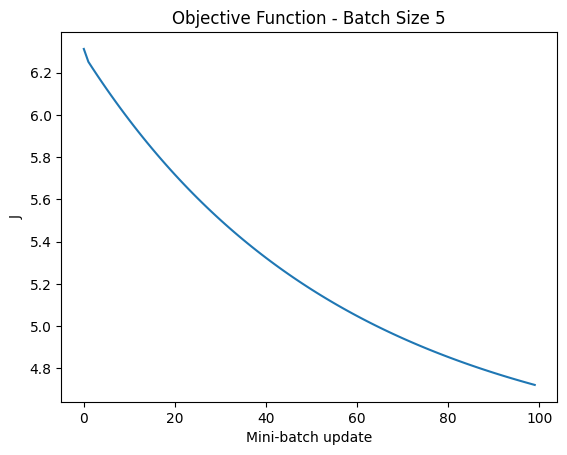

In [ ]:
#m = 20
w = 0
b = 0
alpha = 0.01
epochs = 100
batch_size = 20

J_history_20 = []

m = len(y)

for epoch in range(epochs):
  for start in range(0, m, batch_size):
    end = start + batch_size
    x_batch = x[start:end]
    y_batch = y[start:end]

    m_batch = len(y_batch)

    y_hat = w*x_batch + b
    J = (1/(2*m_batch)) * np.sum((y_hat - y_batch)**2)
    dw = (1/m_batch)*np.sum((y_hat - y_batch)*x_batch)
    db = (1/m_batch)*np.sum(y_hat - y_batch)
    w = w - alpha*dw
    b = b - alpha*db

  # Calculate J using ALL data after the epoch
  y_hat_all = w*x + b
  J = (1/(2*m))*np.sum((y_hat_all - y)**2)

  J_history_20.append(J)


plt.plot(J_history_20)

plt.xlabel("Mini-batch update")
plt.ylabel("J")
plt.title("Objective Function - Batch Size 5")

plt.show()

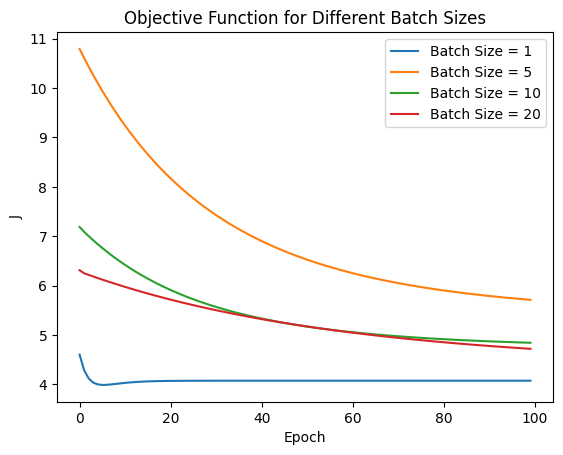

In [ ]:
plt.plot(J_history_1, label="Batch Size = 1")
plt.plot(J_history_5, label="Batch Size = 5")
plt.plot(J_history_10, label="Batch Size = 10")
plt.plot(J_history_20, label="Batch Size = 20")

plt.xlabel("Epoch")
plt.ylabel("J")
plt.title("Objective Function for Different Batch Sizes")
plt.legend()

plt.show()

Batch size is the lowest J, and actually minimizes J around the 5th Epoch, before rising slightly and leveling out.

3) (20 pts.) Use the Scikit-learn breast cancer Wisconsin dataset and a logistic regression
model to classify breast cancers. You must recursively eliminate features to find the best
two features to perform the classification. Evaluate the model using various classification
metrics and report your findings. Use a 70%-30% split.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
cancer = load_breast_cancer()
x = pd.DataFrame(cancer.data, columns = cancer.feature_names)
y = cancer. target
print(x.shape)
print(y.shape)
x.head()

(569, 30)
(569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, train_size = 0.7, random_state = 123, stratify = y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
model = LogisticRegression(max_iter = 10000)
rfe = RFE(estimator = model, n_features_to_select = 2)
rfe.fit(x_train_scaled, y_train)

selected_features = x.columns[rfe.support_]
print(selected_features)


Index(['worst radius', 'worst concave points'], dtype='object')


In [8]:
x_train_rfe = rfe.transform(x_train_scaled)
x_test_rfe = rfe.transform(x_test_scaled)

final_model=LogisticRegression(max_iter=10000)

final_model.fit(x_train_rfe, y_train)
y_pred = final_model.predict(x_test_rfe)


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Accuracy: 0.9590643274853801
Precision: 0.9629629629629629
Recall: 0.9719626168224299
F1 Score: 0.9674418604651163


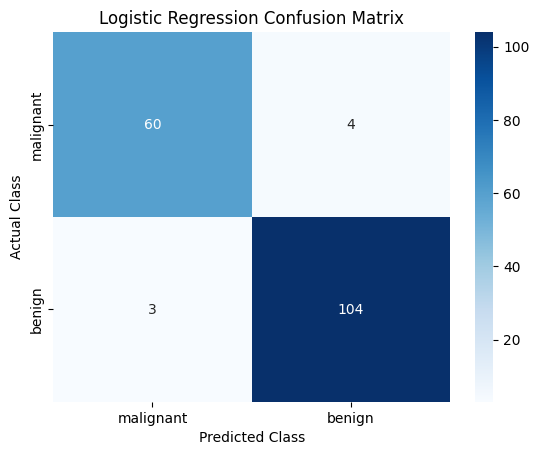

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

4) (25 pts.) Construct a neural network with a single hidden layer containing two neurons
using Tensorflow. Use ReLU as activation function. Optimize the network with stochastic
gradient descent method. Choose mean squared error to calculate the loss. Fit the
housing prices dataset found on LMS using the network. Use the trained neural network
model to predict the price of a house in a city with population of 165, 000. Calculate a
useful regression metric. Plot the training and validation losses. Use a 70%-30% split
for the training and validation dataset. The architecture of the neural network and the
optimizer are fixed for this problem. Therefore, you need to choose a suitable learning
rate and number of epochs to minimize the loss. Explain the trends you found in the
plots for training and validation losses.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
df = pd.read_csv('housing_prices.txt')
df.columns = ['population', 'price']
df.head()

,population,price
0,5.5277,9.1302
1,8.5186,13.6620
2,7.0032,11.8540
3,5.8598,6.8233
4,8.3829,11.8860


In [7]:
x = df[['population']]
y = df[['price']]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 123)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [9]:
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
learning_rate = 0.01
model_1.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss='mean_squared_error')

In [11]:
epochs = 200
history_1 = model_1.fit(x_train_scaled, y_train_scaled, epochs=epochs, batch_size=1, validation_data=(x_test_scaled, y_test_scaled), verbose=0)

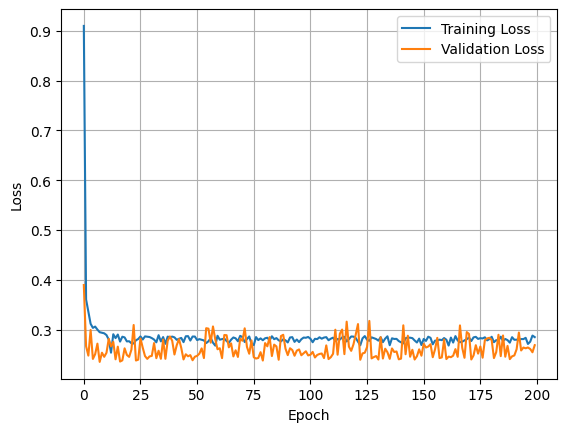

In [14]:
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
y_pred_scaled = model_1.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Mean Absolute Error: 2.0773401260375977


In [17]:
population = np.array([[165.000]])
population_scaled = x_scaler.transform(population)
predicted_scaled = model_1.predict(population_scaled)
predicted_price = y_scaler.inverse_transform(predicted_scaled)
print(f'Predicted Price for Population 165,000: {predicted_price[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Price for Population 165,000: 176.31777954101562


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


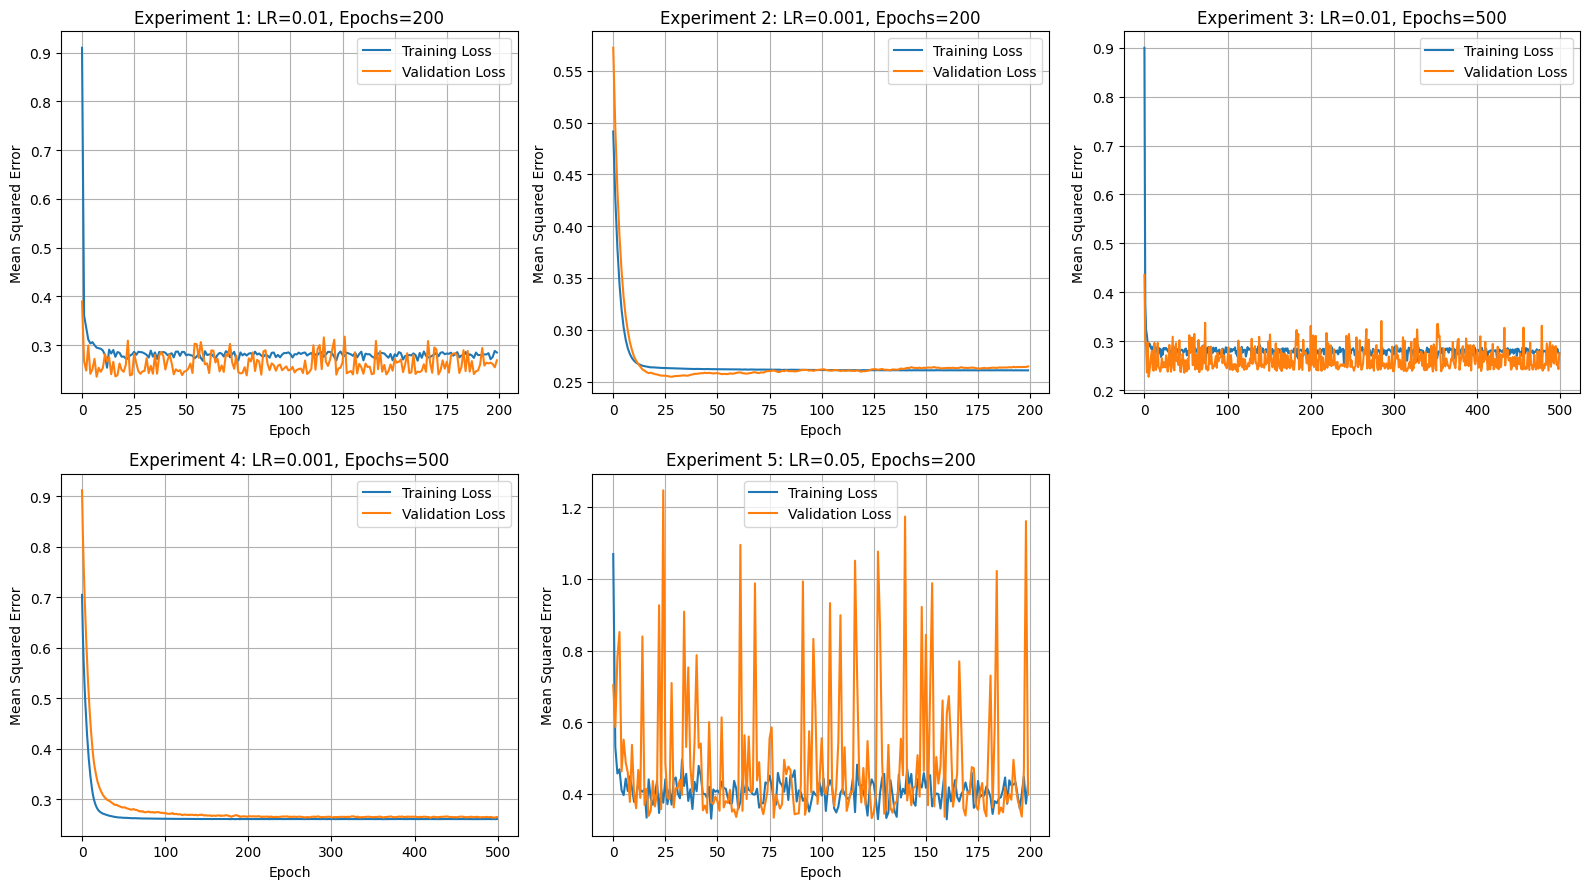

In [18]:
# Experiment 2: Learning Rate = 0.001, Epochs = 200
import tensorflow as tf

model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error'
)

history_2 = model_2.fit(
    x_train_scaled, y_train_scaled,
    epochs=200,
    batch_size=1,
    validation_data=(x_test_scaled, y_test_scaled),
    verbose=0
)


# Experiment 3: Learning Rate = 0.01, Epochs = 500
model_3 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_3.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='mean_squared_error'
)

history_3 = model_3.fit(
    x_train_scaled, y_train_scaled,
    epochs=500,
    batch_size=1,
    validation_data=(x_test_scaled, y_test_scaled),
    verbose=0
)


# Experiment 4: Learning Rate = 0.001, Epochs = 500
model_4 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_4.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error'
)

history_4 = model_4.fit(
    x_train_scaled, y_train_scaled,
    epochs=500,
    batch_size=1,
    validation_data=(x_test_scaled, y_test_scaled),
    verbose=0
)


# Experiment 5: Learning Rate = 0.05, Epochs = 200
model_5 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_5.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='mean_squared_error'
)

history_5 = model_5.fit(
    x_train_scaled, y_train_scaled,
    epochs=200,
    batch_size=1,
    validation_data=(x_test_scaled, y_test_scaled),
    verbose=0
)


# Plot all 5 experiments
histories = [history_1, history_2, history_3, history_4, history_5]

titles = [
    'Experiment 1: LR=0.01, Epochs=200',
    'Experiment 2: LR=0.001, Epochs=200',
    'Experiment 3: LR=0.01, Epochs=500',
    'Experiment 4: LR=0.001, Epochs=500',
    'Experiment 5: LR=0.05, Epochs=200'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, history in enumerate(histories):
    ax = axes.flat[i]

    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')

    ax.set_title(titles[i])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error')
    ax.legend()
    ax.grid(True)

# Hide unused sixth subplot
axes.flat[5].axis('off')

plt.tight_layout()
plt.show()

In [19]:
results = pd.DataFrame({
    'Experiment': [1, 2, 3, 4, 5],
    'Learning Rate': [0.01, 0.001, 0.01, 0.001, 0.05],
    'Epochs': [200, 200, 500, 500, 200],
    'Final Training Loss': [
        h.history['loss'][-1] for h in histories
    ],
    'Final Validation Loss': [
        h.history['val_loss'][-1] for h in histories
    ],
    'Minimum Validation Loss': [
        min(h.history['val_loss']) for h in histories
    ]
})

print(results.to_string(index=False))

 Experiment  Learning Rate  Epochs  Final Training Loss  Final Validation Loss  Minimum Validation Loss
          1          0.010     200             0.285206               0.269027                 0.235403
          2          0.001     200             0.260764               0.264574                 0.254572
          3          0.010     500             0.275706               0.275804                 0.227901
          4          0.001     500             0.260936               0.264946                 0.263486
          5          0.050     200             0.428043               0.397830                 0.332198


While experiment 3 experienced the lowest minimum validation loss, its final validation loss was higher than all those but experiment 5. Looking at the graphs, experiment 2 and 4 are the smoothest, both using a learning rate of 0.001. Option 2 of a learning rate of 0.001 and 200 epochs is likely the best solution because it achieved the lowest final validation loss, behaved much smoother than experiments 1, 3, and 5, and used less epochs than experiment 4, which used 500. This combination between low validation loss, smoothness, and minimized computational cost makes option two a good option for this data.